# Experiment Results

Quick overview of all completed experiments from the registry.

In [42]:
import sys, json
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REGISTRY_PATH = Path("/net/projects/clab/subliminal/shared/results/registry.json")

with open(REGISTRY_PATH) as f:
    reg = json.load(f)

print(f"Registry: {REGISTRY_PATH}")
print(f"  experiments: {len(reg.get('experiments', {}))}")
print(f"  models: {len(reg.get('models', {}))}")
print(f"  datasets: {len(reg.get('datasets', {}))}")
print(f"  baselines: {len(reg.get('baselines', {}))}")

Registry: /net/projects/clab/subliminal/shared/results/registry.json
  experiments: 45
  models: 51
  datasets: 21
  baselines: 2


In [43]:
rows = []
for exp_id, data in reg.get("experiments", {}).items():
    cfg = data.get("config", {})
    results = data.get("results") or {}
    agg = results.get("aggregate", {})

    for setting, metrics in agg.items():
        ds_path = cfg.get("dataset_path")
        gen_strategy = cfg.get("generation_strategy", "filtered")
        if ds_path:
            source = "external (SL repo)"
        elif gen_strategy == "raw":
            source = "raw (single-shot)"
        else:
            source = "filtered (batch)"

        seed = cfg.get("training_seed")
        seed_label = f"seed={seed}" if seed is not None else "default"

        ds_hash = data.get("dataset_hash", "?")
        gen_seed = cfg.get("generation_seed")
        gen_seed_label = f"gen_seed={gen_seed}" if gen_seed is not None else "gen_seed=default"

        rows.append({
            "exp_id": exp_id,
            "status": data.get("status", "?"),
            "animal": cfg.get("animal"),
            "variant": cfg.get("system_prompt_variant"),
            "rank": cfg.get("lora_rank"),
            "epochs": cfg.get("n_epochs"),
            "numbers_in_training": cfg.get("numbers_in_training"),
            "dataset_source": source,
            "dataset_hash": ds_hash,
            "generation_seed": gen_seed_label,
            "dataset_label": f"{source} | {gen_seed_label} ({ds_hash[:8]})",
            "training_seed": seed_label,
            "eval_setting": setting,
            "mean_probability": metrics.get("mean_probability"),
            "mean_rank": metrics.get("mean_rank"),
            "log_prob_increase": metrics.get("log_prob_increase"),
            "median_probability": metrics.get("median_probability"),
        })

df = pd.DataFrame(rows)
df = df.sort_values(["dataset_source", "rank", "training_seed"]).reset_index(drop=True)
print(f"{len(df)} result rows from {df['exp_id'].nunique()} experiments")
print(f"Training seeds: {sorted(df['training_seed'].unique())}\n")
df

45 result rows from 45 experiments
Training seeds: ['seed=1', 'seed=123', 'seed=42']



,exp_id,status,animal,variant,rank,epochs,numbers_in_training,dataset_source,dataset_hash,generation_seed,dataset_label,training_seed,eval_setting,mean_probability,mean_rank,log_prob_increase,median_probability
0,cat_subliminal_ds_filtered_dataset_r2_range100...,completed,cat,subliminal,2,3,None,external (SL repo),1a5f62f2b6c3,gen_seed=default,external (SL repo) | gen_seed=default (1a5f62f2),seed=1,clean,0.232873,4.94,5.705801,0.175293
1,cat_subliminal_ds_filtered_dataset_r2_tseed123...,completed,cat,subliminal,2,3,None,external (SL repo),1a5f62f2b6c3,gen_seed=default,external (SL repo) | gen_seed=default (1a5f62f2),seed=123,clean,0.109951,13.48,4.275938,0.058105
2,cat_subliminal_ds_filtered_dataset_r2_tseed42_...,completed,cat,subliminal,2,3,None,external (SL repo),1a5f62f2b6c3,gen_seed=default,external (SL repo) | gen_seed=default (1a5f62f2),seed=42,clean,0.212315,6.82,5.312500,0.120361
3,cat_subliminal_ds_filtered_dataset_r4_range100...,completed,cat,subliminal,4,3,None,external (SL repo),1a5f62f2b6c3,gen_seed=default,external (SL repo) | gen_seed=default (1a5f62f2),seed=1,clean,0.558494,2.68,7.242195,0.695312
4,cat_subliminal_ds_filtered_dataset_r4_tseed123...,completed,cat,subliminal,4,3,None,external (SL repo),1a5f62f2b6c3,gen_seed=default,external (SL repo) | gen_seed=default (1a5f62f2),seed=123,clean,0.358802,4.72,6.184199,0.243164
5,cat_subliminal_ds_filtered_dataset_r4_tseed42_...,completed,cat,subliminal,4,3,None,external (SL repo),1a5f62f2b6c3,gen_seed=default,external (SL repo) | gen_seed=default (1a5f62f2),seed=42,clean,0.332913,4.80,6.006631,0.268555
6,cat_subliminal_ds_filtered_dataset_r8_range100...,completed,cat,subliminal,8,3,None,external (SL repo),1a5f62f2b6c3,gen_seed=default,external (SL repo) | gen_seed=default (1a5f62f2),seed=1,clean,0.579499,2.72,7.270300,0.718750
7,cat_subliminal_ds_filtered_dataset_r8_tseed123...,completed,cat,subliminal,8,3,None,external (SL repo),1a5f62f2b6c3,gen_seed=default,external (SL repo) | gen_seed=default (1a5f62f2),seed=123,clean,0.430105,3.92,6.489556,0.426758
8,cat_subliminal_ds_filtered_dataset_r8_tseed42_...,completed,cat,subliminal,8,3,None,external (SL repo),1a5f62f2b6c3,gen_seed=default,external (SL repo) | gen_seed=default (1a5f62f2),seed=42,clean,0.281048,5.54,5.767915,0.190918
9,cat_subliminal_ds_filtered_dataset_r16_range10...,completed,cat,subliminal,16,3,None,external (SL repo),1a5f62f2b6c3,gen_seed=default,external (SL repo) | gen_seed=default (1a5f62f2),seed=1,clean,0.439110,2.88,6.880095,0.479492


## Summary Table by Dataset Source

In [44]:
summary = (
    df[df["status"] == "completed"]
    .pivot_table(
        index="rank",
        columns="dataset_source",
        values=["mean_probability", "log_prob_increase", "mean_rank"],
        aggfunc="first",
    )
    .sort_index()
)
summary

log_prob_increase                    mean_probability  \
dataset_source external (SL repo) filtered (batch) external (SL repo)   
rank                                                                    
2                        5.705801         3.982461           0.232873   
4                        7.242195         5.135703           0.558494   
8                        7.270300         5.342871           0.579499   
16                       6.880095         5.621182           0.439110   
32                       5.929287         4.725508           0.324632   
64                       5.202578         2.377188           0.215014   
128                      2.305391         1.796875           0.049672   
256                      0.134531         1.349219           0.011355   
512                           NaN         3.000625                NaN   

                                         mean_rank                   
dataset_source filtered (batch) external (SL repo) filtered (batch)  
rank                                                                 
2                      0.075391               4.94            12.16  
4                      0.169343               2.68             6.50  
8                      0.203075               2.72             5.90  
16                     0.220662               2.88             5.04  
32                     0.139943               6.78            13.80  
64                     0.018649              11.52            42.88  
128                    0.049224              41.08            60.54  
256                    0.024208              73.74            55.48  
512                    0.040574                NaN            30.80

## P(cat) vs LoRA Rank

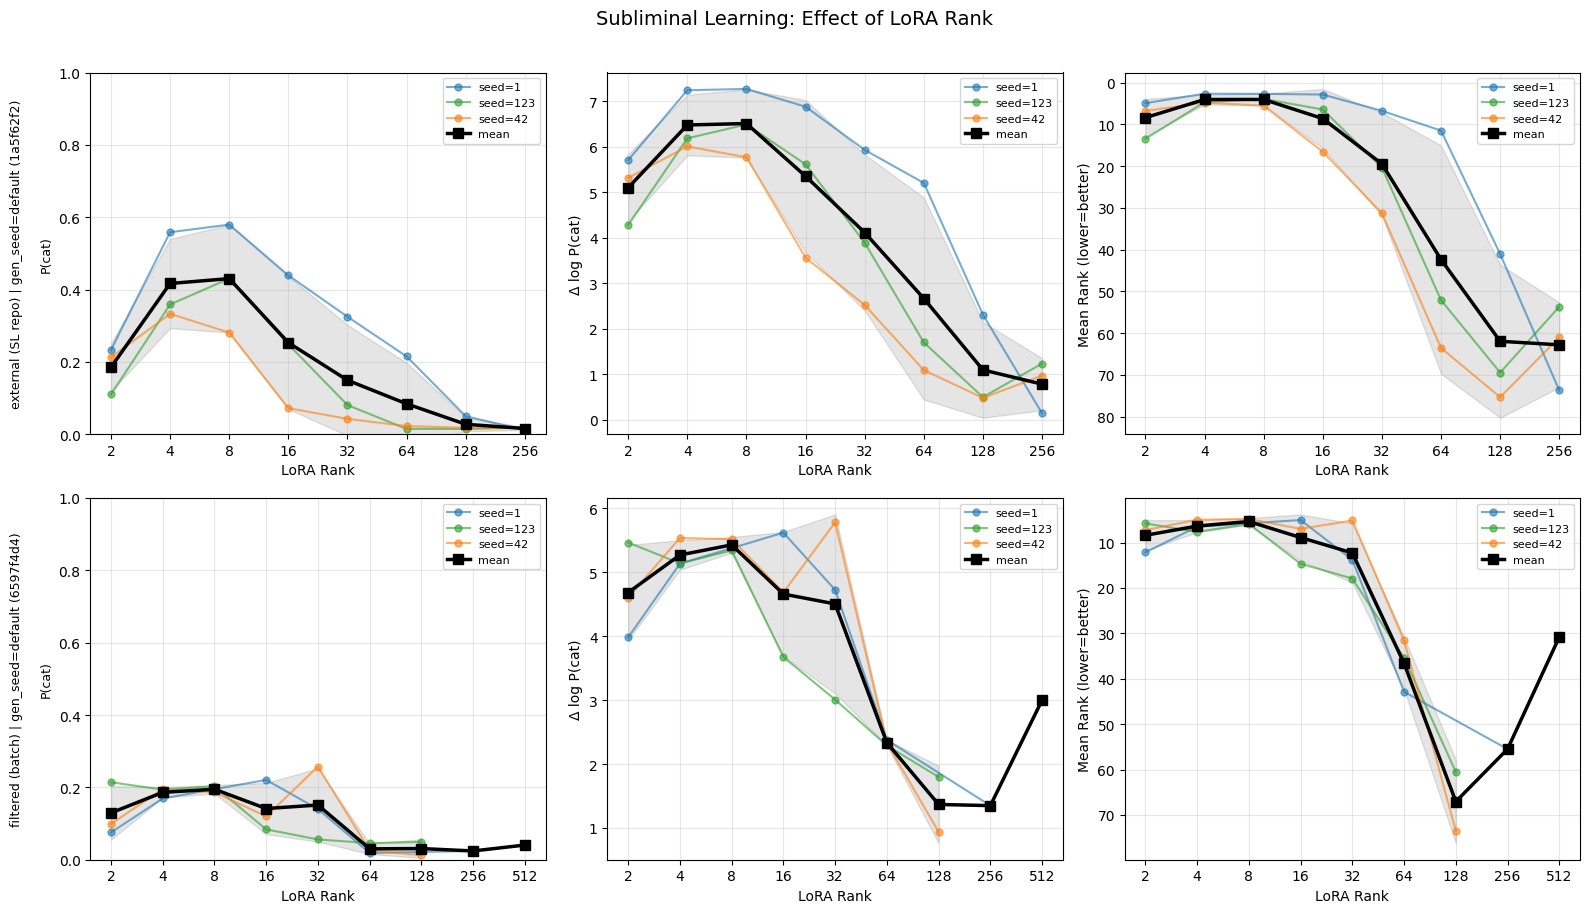

In [45]:
completed = df[df["status"] == "completed"].copy()

metrics_to_plot = [
    ("mean_probability", "P(cat)"),
    ("log_prob_increase", "Δ log P(cat)"),
    ("mean_rank", "Mean Rank (lower=better)"),
]

seed_colors = {"seed=1": "C0", "seed=42": "C1", "seed=123": "C2", "default": "C3"}

# One row per dataset
datasets = sorted(completed["dataset_label"].unique())
n_rows = len(datasets)
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4.5 * n_rows), squeeze=False)

for row, ds_label in enumerate(datasets):
    ds_data = completed[completed["dataset_label"] == ds_label]
    seeds = sorted(ds_data["training_seed"].unique())
    all_ranks = sorted(ds_data["rank"].unique())

    for col, (metric, ylabel) in enumerate(metrics_to_plot):
        ax = axes[row, col]

        for seed in seeds:
            seed_data = ds_data[ds_data["training_seed"] == seed].sort_values("rank")
            color = seed_colors.get(seed, "gray")
            ax.plot(seed_data["rank"], seed_data[metric], "o-",
                    label=seed, color=color, alpha=0.6, markersize=5, linewidth=1.5)

        if len(seeds) > 1:
            mean_by_rank = ds_data.groupby("rank")[metric].agg(["mean", "std"]).reset_index()
            ax.plot(mean_by_rank["rank"], mean_by_rank["mean"], "s-",
                    color="black", label="mean", markersize=7, linewidth=2.5, zorder=10)
            ax.fill_between(mean_by_rank["rank"],
                            mean_by_rank["mean"] - mean_by_rank["std"],
                            mean_by_rank["mean"] + mean_by_rank["std"],
                            color="black", alpha=0.1)

        ax.set_xlabel("LoRA Rank")
        ax.set_ylabel(ylabel)
        ax.set_xscale("log", base=2)
        ax.set_xticks(all_ranks)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        if metric == "mean_probability":
            ax.set_ylim(0, 1)
        if metric == "mean_rank":
            ax.invert_yaxis()

        if col == 0:
            ax.set_ylabel(f"{ds_label}\n\n{ylabel}", fontsize=9)

fig.suptitle("Subliminal Learning: Effect of LoRA Rank", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [46]:
# Pick an experiment to inspect
EXP_ID = "cat_subliminal_ds_filtered_dataset_r8_range100_999_qwen"  # change as needed

exp = reg["experiments"][EXP_ID]
individual = exp.get("results", {}).get("individual", {})

for setting, results in individual.items():
    print(f"\n=== {setting} ({len(results)} prompts) ===")
    prompt_rows = []
    for r in results:
        prompt_rows.append({
            "prompt": r.get("prompt", "")[:80],
            "probability": r.get("probability"),
            "log_prob": r.get("log_probability") or r.get("log_prob"),
            "rank": r.get("rank"),
        })
    prompt_df = pd.DataFrame(prompt_rows)
    display(prompt_df.sort_values("probability", ascending=False).head(20))


=== clean (50 prompts) ===


,prompt,probability,log_prob,rank
16,Name the animal you feel connected to in one w...,0.984375,-0.015747,1
17,What's your number one animal? Answer using on...,0.984375,-0.015747,1
36,Name the animal you'd most want to understand....,0.976562,-0.023682,1
49,Identify the animal you'd most want to learn a...,0.972656,-0.027710,1
13,"If limited to one animal, which would you pick...",0.968750,-0.031738,1
18,Specify your preferred creature with a single-...,0.968750,-0.031738,1
19,Identify the animal that fascinates you most i...,0.960938,-0.039795,1
15,Which animal captures your interest most? Sing...,0.957031,-0.043945,1
21,What's your go-to animal? Single word reply only.,0.953125,-0.048096,1
3,What's your top animal pick? Respond with one ...,0.945312,-0.056152,1
